# Simulation 1: nearby and distant mixture components

This notebook studies whether observation matching can retain component geometry after a conventional co-clustering summary has saturated. Four Gaussian groups form two nearby pairs separated by a much larger gap. The fit uses neither the generating labels nor their ordering; labels enter only the displayed evaluation.

The default deterministic run uses a shorter chain for interactive use. Set `PAPER_SCALE=True` to restore the manuscript settings recorded below.


In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "bmts.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bmts

bmts.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = False
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")


Public root located. PAPER_SCALE=False


In [2]:
rng = np.random.default_rng(20260703)
true_means = np.array([[0.0, 0.0], [1.7, 0.0], [6.0, 0.0], [7.7, 0.0]])
sigma = 0.45
n_per_group = 25
X = np.vstack([rng.normal(mean, sigma, size=(n_per_group, 2)) for mean in true_means])
labels = np.repeat(np.arange(4), n_per_group)

# A label-free row permutation prevents source ordering from affecting initialization.
permutation = np.random.default_rng(2308).permutation(len(X))
X, labels = X[permutation], labels[permutation]

settings = (
    {"iterations": 1800, "burn": 600, "thin": 4}
    if PAPER_SCALE
    else {"iterations": 900, "burn": 300, "thin": 3}
)
fit = bmts.sample_isotropic_gmm(
    X,
    4,
    sigma**2,
    concentration=1.0,
    prior_variance=100.0,
    seed=2307,
    **settings,
)
posterior = bmts.posterior_bmts(fit.means, fit.responsibilities)
psm_complement = 1.0 - bmts.rao_blackwell_psm(fit.responsibilities)

upper = np.triu_indices(len(X), k=1)
left, right = labels[upper[0]], labels[upper[1]]
category_masks = {
    "Within component": left == right,
    "Nearby cross-component": (
        ((left == 0) & (right == 1))
        | ((left == 1) & (right == 0))
        | ((left == 2) & (right == 3))
        | ((left == 3) & (right == 2))
    ),
    "Distant cross-component": (
        ((left <= 1) & (right >= 2)) | ((right <= 1) & (left >= 2))
    ),
}

rows = []
for name, mask in category_masks.items():
    pair_index = (upper[0][mask], upper[1][mask])
    rows.append(
        {
            "pair category": name,
            "pairs": int(mask.sum()),
            "mean PSM complement": psm_complement[pair_index].mean(),
            "mean BMTS": posterior.mean[pair_index].mean(),
            "median 90% width": np.median(posterior.width[pair_index]),
        }
    )
summary = pd.DataFrame(rows)
print(f"Retained posterior draws: {fit.n_draws}")
display(summary.round(3))
paper_study = paper["study1"]
pd.DataFrame({
    "paper-scale category": ["Within component", "Nearby cross-component", "Distant cross-component"],
    "mean PSM complement": [paper_study[key]["psm_comp_mean"] for key in ("within", "near_cross", "distant_cross")],
    "mean BMTS": [paper_study[key]["bmts_mean"] for key in ("within", "near_cross", "distant_cross")],
    "median 90% width": [paper_study[key]["median_ci_width"] for key in ("within", "near_cross", "distant_cross")],
}).round(3)


Retained posterior draws: 200


,pair category,pairs,mean PSM complement,mean BMTS,median 90% width
0,Within component,1200,0.047,0.079,0.027
1,Nearby cross-component,1250,0.952,1.771,0.430
2,Distant cross-component,2500,1.000,5.996,0.479


,paper-scale category,mean PSM complement,mean BMTS,median 90% width
0,Within component,0.047,0.079,0.029
1,Nearby cross-component,0.951,1.774,0.428
2,Distant cross-component,1.000,5.993,0.480


## Mixture geometry


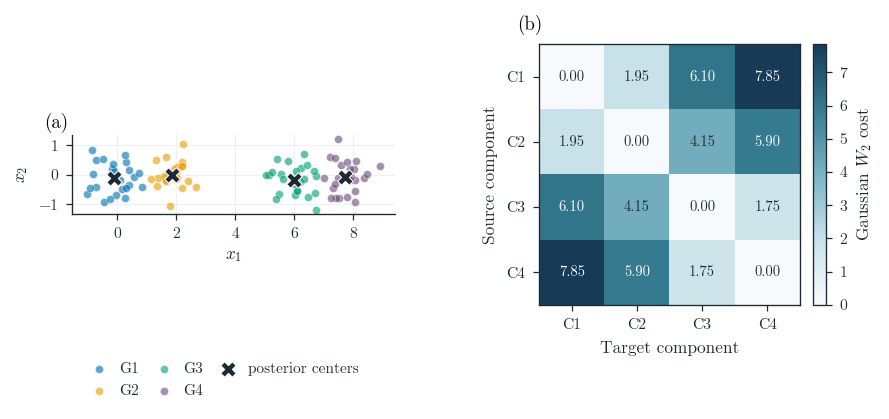

In [3]:
mean_order = np.argsort(fit.means.mean(axis=0)[:, 0])
posterior_means = fit.means.mean(axis=0)[mean_order]
ground_cost = bmts.gaussian_w2_ground_cost(posterior_means)

fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.85), constrained_layout=False)
fig.subplots_adjust(bottom=0.27, wspace=0.34)
for group in range(4):
    mask = labels == group
    axes[0].scatter(
        X[mask, 0], X[mask, 1], s=15,
        color=bmts.CATEGORY_COLORS[group], alpha=0.62,
        edgecolor="white", linewidth=0.3, label=f"G{group + 1}",
    )
axes[0].scatter(
    posterior_means[:, 0], posterior_means[:, 1], marker="X", s=55,
    color=bmts.INK, edgecolor="white", linewidth=0.5, label="posterior centers",
)
axes[0].set(xlabel=r"$x_1$", ylabel=r"$x_2$")
axes[0].set_aspect("equal", adjustable="box")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, ncol=3, loc="lower center", bbox_to_anchor=(0.28, 0.02))
bmts.finish_axes(axes[0], "both")
bmts.panel_label(axes[0], "(a)")

image = axes[1].imshow(ground_cost, cmap=bmts.SEQUENTIAL_CMAP, vmin=0)
axes[1].set_xticks(range(4), [f"C{k + 1}" for k in range(4)])
axes[1].set_yticks(range(4), [f"C{k + 1}" for k in range(4)])
axes[1].set(xlabel="Target component", ylabel="Source component")
for i in range(4):
    for j in range(4):
        color = "white" if ground_cost[i, j] > ground_cost.max() * 0.55 else bmts.INK
        axes[1].text(j, i, f"{ground_cost[i, j]:.2f}", ha="center", va="center", color=color, fontsize=7)
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label="Gaussian $W_2$ cost")
bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 1.** Panel (a) shows the generated observations and posterior component centers; panel (b) shows the corresponding component ground-cost matrix. The close pairs C1–C2 and C3–C4 are visibly distinct from the gap between the two larger regions.


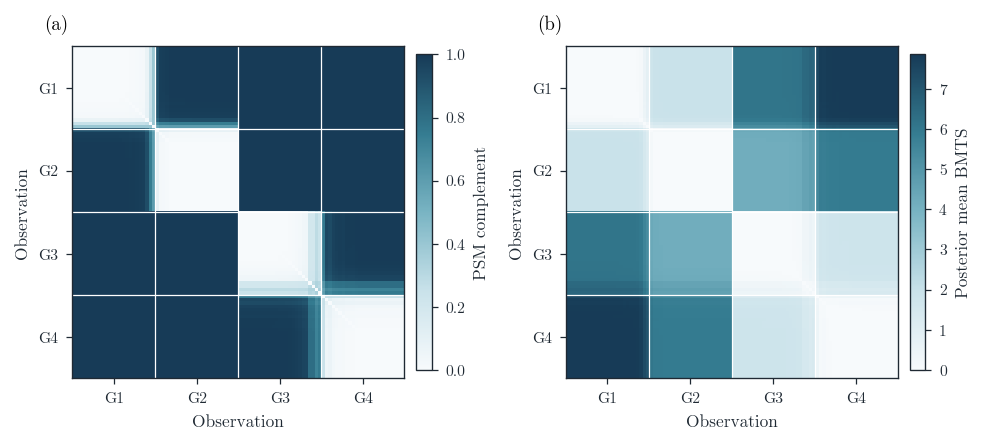

In [4]:
display_order = np.lexsort((X[:, 0], labels))
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.85), constrained_layout=True)
images = [
    axes[0].imshow(
        psm_complement[np.ix_(display_order, display_order)],
        cmap=bmts.SEQUENTIAL_CMAP, vmin=0, vmax=1, interpolation="nearest",
    ),
    axes[1].imshow(
        posterior.mean[np.ix_(display_order, display_order)],
        cmap=bmts.SEQUENTIAL_CMAP, interpolation="nearest",
    ),
]
for index, (ax, image, label) in enumerate(zip(axes, images, ["PSM complement", "Posterior mean BMTS"])):
    for boundary in [25, 50, 75]:
        ax.axhline(boundary - 0.5, color="white", lw=0.6)
        ax.axvline(boundary - 0.5, color="white", lw=0.6)
    ax.set_xticks([12, 37, 62, 87], ["G1", "G2", "G3", "G4"])
    ax.set_yticks([12, 37, 62, 87], ["G1", "G2", "G3", "G4"])
    ax.set(xlabel="Observation", ylabel="Observation")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.035, label=label)
    bmts.panel_label(ax, f"({chr(97 + index)})")
plt.show()


**Figure 2.** Panel (a) is the Rao–Blackwellized posterior-similarity complement. Panel (b) is posterior mean BMTS. Both recognize cross-component pairs, but only BMTS preserves how far apart their supporting components are.


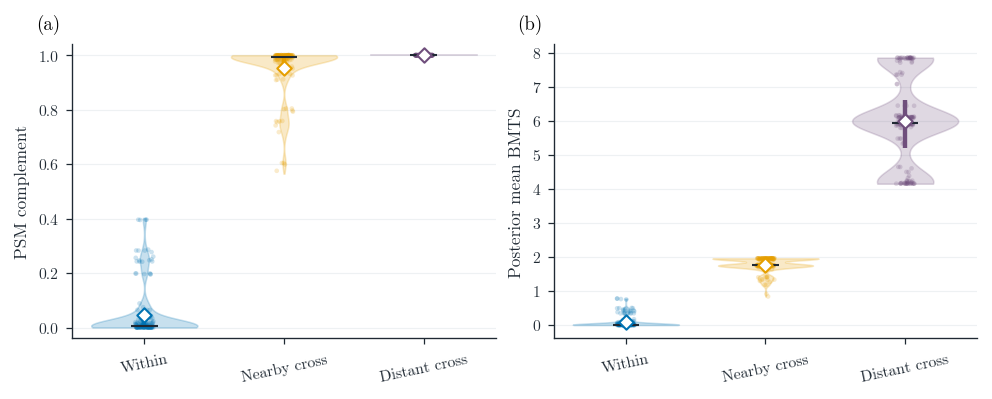

In [5]:
psm_values = [psm_complement[upper][mask] for mask in category_masks.values()]
bmts_values = [posterior.mean[upper][mask] for mask in category_masks.values()]
short_labels = ["Within", "Nearby cross", "Distant cross"]
colors = [bmts.BLUE, bmts.ORANGE, bmts.PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.55), constrained_layout=True)
bmts.draw_violin_summary(axes[0], psm_values, colors, seed=8103)
bmts.draw_violin_summary(axes[1], bmts_values, colors, seed=8104)
for index, (ax, ylabel) in enumerate(zip(axes, ["PSM complement", "Posterior mean BMTS"])):
    ax.set_xticks([1, 2, 3], short_labels, rotation=12)
    ax.set_ylabel(ylabel)
    bmts.panel_label(ax, f"({chr(97 + index)})")
axes[0].set_ylim(-0.04, 1.04)
plt.show()


**Figure 3.** Pair-category distributions for (a) the PSM complement and (b) posterior mean BMTS. Nearby and distant cross-component pairs both have almost complete non-co-clustering, while BMTS separates them through the learned geometry.


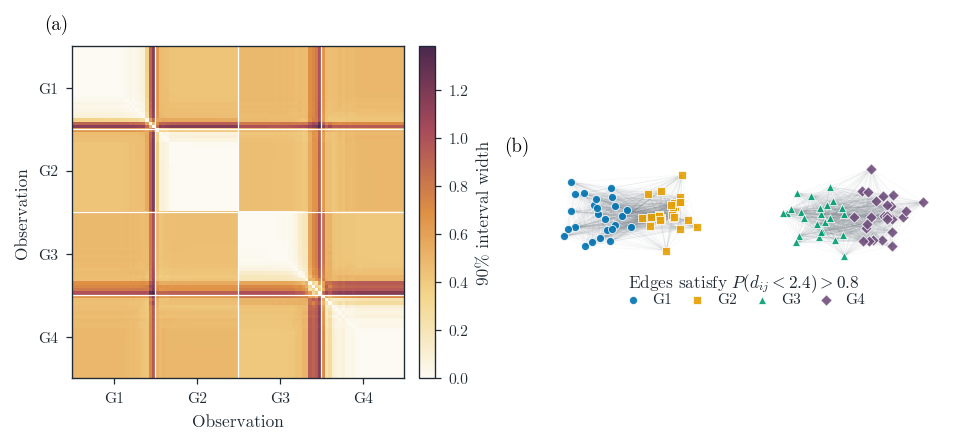

In [6]:
tolerance = 2.4
relation_probability = (posterior.draws < tolerance).mean(axis=0)
adjacency = relation_probability > 0.8
np.fill_diagonal(adjacency, False)

fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.85), constrained_layout=True)
width_image = axes[0].imshow(
    posterior.width[np.ix_(display_order, display_order)],
    cmap=bmts.UNCERTAINTY_CMAP, interpolation="nearest",
)
for boundary in [25, 50, 75]:
    axes[0].axhline(boundary - 0.5, color="white", lw=0.6)
    axes[0].axvline(boundary - 0.5, color="white", lw=0.6)
axes[0].set_xticks([12, 37, 62, 87], ["G1", "G2", "G3", "G4"])
axes[0].set_yticks([12, 37, 62, 87], ["G1", "G2", "G3", "G4"])
axes[0].set(xlabel="Observation", ylabel="Observation")
fig.colorbar(width_image, ax=axes[0], fraction=0.046, pad=0.035, label="90% interval width")
bmts.panel_label(axes[0], "(a)")

bmts.draw_relation_graph(
    axes[1], X, adjacency, groups=labels,
    group_names=["G1", "G2", "G3", "G4"],
    edge_values=relation_probability, edge_alpha=0.11, node_size=15,
)
axes[1].set_xlabel(rf"Edges satisfy $P(d_{{ij}}<{tolerance})>0.8$")
axes[1].legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 4.** Panel (a) maps posterior interval width. Panel (b) turns the full posterior into a relation graph at the prespecified tolerance; its edges join the two nearby component pairs while respecting the large central gap.


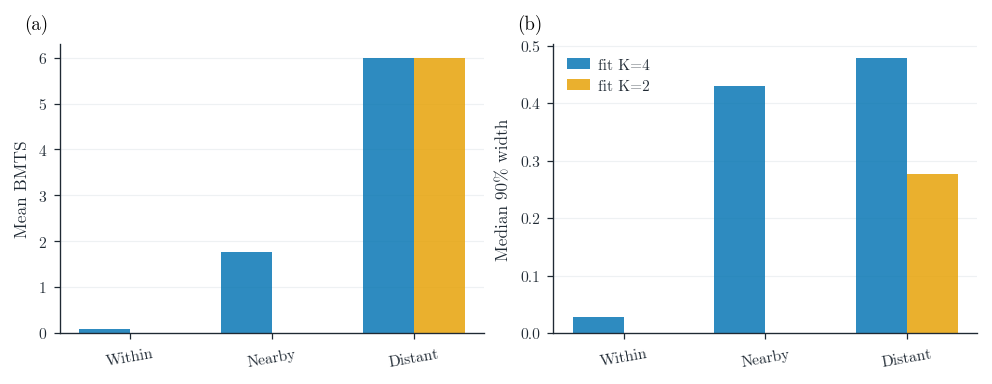

,category,K=4 mean BMTS,K=2 mean BMTS
0,Within,0.079,0.000
1,Nearby cross,1.771,0.000
2,Distant cross,5.996,5.989


In [7]:
stress_settings = (
    {"iterations": 1200, "burn": 400, "thin": 4}
    if PAPER_SCALE
    else {"iterations": 700, "burn": 250, "thin": 5}
)
stress_fit = bmts.sample_isotropic_gmm(
    X, 2, sigma**2, seed=3911, concentration=1.0,
    prior_variance=100.0, **stress_settings,
)
stress_posterior = bmts.posterior_bmts(
    stress_fit.means, stress_fit.responsibilities
)

primary_means = [posterior.mean[upper][mask].mean() for mask in category_masks.values()]
stress_means = [stress_posterior.mean[upper][mask].mean() for mask in category_masks.values()]
primary_widths = [np.median(posterior.width[upper][mask]) for mask in category_masks.values()]
stress_widths = [np.median(stress_posterior.width[upper][mask]) for mask in category_masks.values()]

x = np.arange(3)
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.45), constrained_layout=True)
for ax, first, second, ylabel in [
    (axes[0], primary_means, stress_means, "Mean BMTS"),
    (axes[1], primary_widths, stress_widths, "Median 90% width"),
]:
    ax.bar(x - 0.18, first, 0.36, color=bmts.BLUE, alpha=0.82, label="fit K=4")
    ax.bar(x + 0.18, second, 0.36, color=bmts.ORANGE, alpha=0.82, label="fit K=2")
    ax.set_xticks(x, ["Within", "Nearby", "Distant"], rotation=10)
    ax.set_ylabel(ylabel)
    bmts.finish_axes(ax, "y")
axes[1].legend(loc="upper left")
bmts.panel_label(axes[0], "(a)")
bmts.panel_label(axes[1], "(b)")
plt.show()

pd.DataFrame(
    {"category": short_labels, "K=4 mean BMTS": primary_means, "K=2 mean BMTS": stress_means}
).round(3)


**Figure 5.** The K=2 stress fit deliberately merges the nearby subgroups. Panel (a) shows attenuation of the corresponding geometric contrast; panel (b) shows how posterior width changes. This is a useful limitation: BMTS enriches the fitted mixture representation but cannot recover geometry that the component dictionary omits.
